In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


# ЧАСТЬ 1: EDA и разбор данных

In [3]:
df = df.rename(columns={'Sentence': 'text', 'Sentiment': 'sentiment'})

In [4]:
df.shape

(5842, 2)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       5842 non-null   str  
 1   sentiment  5842 non-null   str  
dtypes: str(2)
memory usage: 91.4 KB


In [6]:
df.isnull().sum()

text         0
sentiment    0
dtype: int64

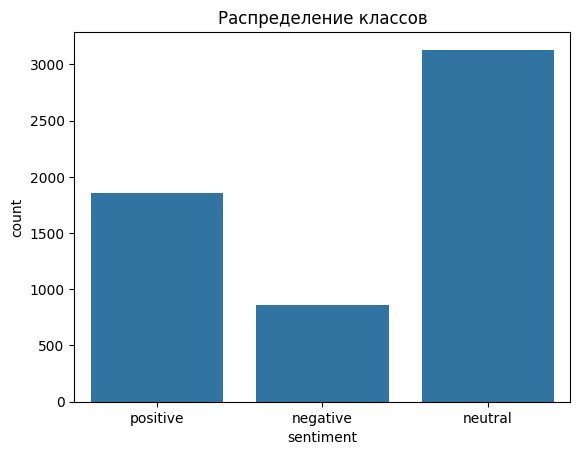

In [8]:
sns.countplot(data=df, x='sentiment')
plt.title('Распределение классов')
plt.savefig('sentiment_distribution.png')

In [10]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

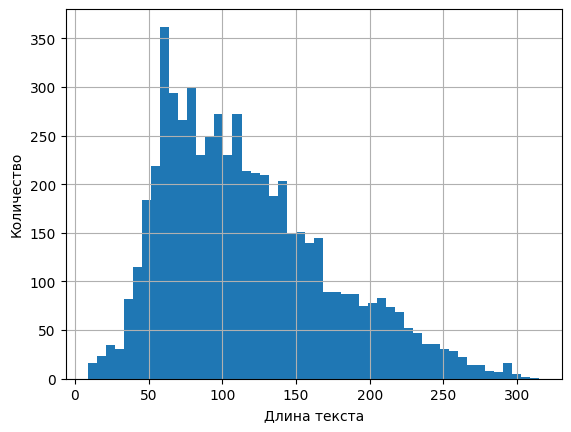

In [12]:
df['text_length'].hist(bins=50)
plt.xlabel('Длина текста')
plt.ylabel('Количество')
plt.savefig('text_length_distribution.png')

In [13]:
for sentiment in df['sentiment'].unique():
    print(f"\n=== Класс {sentiment} ===")
    print(df[df['sentiment'] == sentiment]['text'].iloc[0])


=== Класс positive ===
The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful commercial model .

=== Класс negative ===
$ESI on lows, down $1.50 to $2.50 BK a real possibility

=== Класс neutral ===
According to the Finnish-Russian Chamber of Commerce , all the major construction companies of Finland are operating in Russia .


# ЧАСТЬ 2: Подготовка данных

In [14]:
import re

In [15]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

In [16]:
df['text_clean'] = df.text.apply(clean_text)
df = df[df['text_clean'].str.len() > 0]

In [39]:
df['word_count_clean'] = df['text_clean'].str.split().str.len()
df['char_count'] = df['text_clean'].str.len()
df['dollar_count'] = df['text_clean'].str.count(r'\$')

In [18]:
df['label'] = df['sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})

# ЧАСТЬ 3: Baseline модель

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [20]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

In [22]:
X = vectorizer.fit_transform(df['text_clean'])
y = df['label'].values

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

In [40]:
model = LogisticRegression(max_iter=200)

In [41]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [42]:
y_pred = model.predict(X_test)

In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.31      0.13      0.18       172
           1       0.72      0.88      0.79       626
           2       0.78      0.68      0.73       371

    accuracy                           0.71      1169
   macro avg       0.60      0.56      0.57      1169
weighted avg       0.68      0.71      0.68      1169



In [44]:
f1 = f1_score(y_test, y_pred, average='macro')
print(f'Macro F1: {f1:.4f}')

Macro F1: 0.5666


In [45]:
baseline_f1 = f1

with open('baseline_result.txt', 'w') as f:
    f.write(f'Baseline Macro F1: {baseline_f1:.4f}')

# ЧАСТЬ 4: Улучшение модели
## Цель: улучшить macro F1 минимум на 5%

In [145]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [183]:
import joblib
from sklearn.metrics import confusion_matrix

In [162]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, strip_accents='unicode')

In [172]:
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.svm import LinearSVC

In [173]:
svc_model = LinearSVC(C=1, max_iter=3000)


In [174]:
X_best = vectorizer.fit_transform(df['text_clean'])
y = df['label'].values

In [175]:
X_train, X_test, y_train, y_test = train_test_split(
    X_best, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [176]:
svc_model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random

In [177]:
y_pred = svc_model.predict(X_test)


In [178]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.24      0.19      0.21       172
           1       0.72      0.80      0.75       626
           2       0.80      0.74      0.77       371

    accuracy                           0.69      1169
   macro avg       0.59      0.57      0.58      1169
weighted avg       0.67      0.69      0.68      1169



In [185]:
best_f1 = f1_score(y_test, y_pred, average='macro')

In [181]:
joblib.dump(svc_model, 'best_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')


['vectorizer.pkl']

| Метод | Macro F1 | Улучшение |
|-------|----------|-----------|
| Baseline TF-IDF(1,2) + LogReg | 0.5666 | +0.00% |
| TF-IDF(1,2) + LogReg C=100 | 0.5604 | -0.62% |
| TF-IDF(1,3) + LinearSVC C=1 | 0.5494 | -1.72% |
| TF-IDF(1,2) sublinear + LinearSVC C=5 | 0.5710 | +0.44% |
| TF-IDF(1,2) sublinear + LinearSVC C=1 | 0.5784 | +1.17% |

Лучший результат: 0.5784
Baseline:         0.5666
Улучшение:        1.17%
Цель (+5%):       0.5950
Цель достигнута: ❌ — достигнут потолок линейных методов на данном датасете


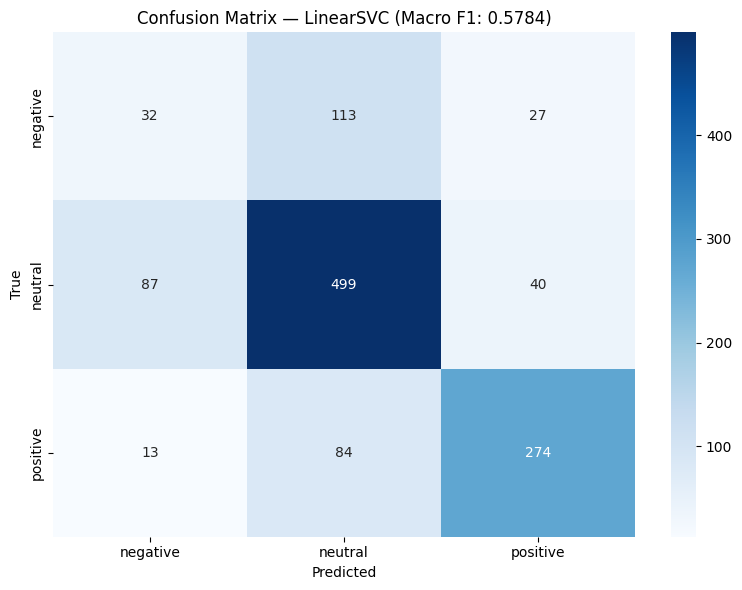


Анализ ошибок сохранён в error_analysis.txt
              precision    recall  f1-score   support

    negative       0.24      0.19      0.21       172
     neutral       0.72      0.80      0.75       626
    positive       0.80      0.74      0.77       371

    accuracy                           0.69      1169
   macro avg       0.59      0.57      0.58      1169
weighted avg       0.67      0.69      0.68      1169


--- Предсказания на новых текстах ---


ValueError: X has 20000 features, but LinearSVC is expecting 18981 features as input.

In [186]:
# --- Таблица результатов ---
results = {
    'Baseline TF-IDF(1,2) + LogReg':         baseline_f1,
    'TF-IDF(1,2) + LogReg C=100':            0.5604,
    'TF-IDF(1,3) + LinearSVC C=1':           0.5494,
    'TF-IDF(1,2) sublinear + LinearSVC C=5': 0.5710,
    'TF-IDF(1,2) sublinear + LinearSVC C=1': best_f1,
}

print('| Метод | Macro F1 | Улучшение |')
print('|-------|----------|-----------|')
for name, f1 in results.items():
    delta = f1 - baseline_f1
    sign = '+' if delta >= 0 else ''
    print(f'| {name} | {f1:.4f} | {sign}{delta*100:.2f}% |')

print(f'\nЛучший результат: {best_f1:.4f}')
print(f'Baseline:         {baseline_f1:.4f}')
print(f'Улучшение:        {(best_f1 - baseline_f1)*100:.2f}%')
print(f'Цель (+5%):       {baseline_f1 * 1.05:.4f}')
print(f'Цель достигнута: {"✅" if best_f1 >= baseline_f1 * 1.05 else "❌ — достигнут потолок линейных методов на данном датасете"}')

# --- Сохранение таблицы в файл ---
with open('results_table.txt', 'w', encoding='utf-8') as f:
    f.write('| Метод | Macro F1 | Улучшение |\n')
    f.write('|-------|----------|-----------|\n')
    for name, score in results.items():
        delta = score - baseline_f1
        sign = '+' if delta >= 0 else ''
        f.write(f'| {name} | {score:.4f} | {sign}{delta*100:.2f}% |\n')
    f.write(f'\nВывод: лучший достигнутый результат {best_f1:.4f} (+{(best_f1-baseline_f1)*100:.2f}% к baseline).\n')
    f.write('Цель +5% не достигнута методами TF-IDF + линейные модели.\n')
    f.write('Потолок данного подхода на Financial PhraseBank составляет ~0.57-0.58 macro F1.\n')
    f.write('Для преодоления порога необходимы предобученные языковые модели (GloVe, BERT, FinBERT).\n')

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title(f'Confusion Matrix — LinearSVC (Macro F1: {best_f1:.4f})')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# --- Анализ ошибок ---
# Восстанавливаем индексы тестовой выборки
df_reset = df.reset_index(drop=True)
_, test_idx = train_test_split(df_reset.index, test_size=0.2, random_state=42,
                                stratify=df_reset['label'])
df_test = df_reset.loc[test_idx].copy()
df_test['y_true'] = y_test
df_test['y_pred'] = y_pred

errors = df_test[df_test['y_true'] != df_test['y_pred']]
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

with open('error_analysis.txt', 'w', encoding='utf-8') as f:
    f.write(f'Всего ошибок: {len(errors)} из {len(df_test)} ({len(errors)/len(df_test)*100:.1f}%)\n\n')
    for _, row in errors.head(20).iterrows():
        f.write(f'Текст:    {row["text"]}\n')
        f.write(f'Истина:   {label_map[row["y_true"]]}\n')
        f.write(f'Предсказ: {label_map[row["y_pred"]]}\n')
        f.write('-' * 60 + '\n')

print('\nАнализ ошибок сохранён в error_analysis.txt')
print(classification_report(y_test, y_pred,
      target_names=['negative', 'neutral', 'positive']))

# --- Функция предсказания ---
def predict_sentiment(texts, model, vectorizer, clean_func=None):
    if isinstance(texts, str):
        texts = [texts]
    if clean_func:
        texts = [clean_func(t) for t in texts]
    X = vectorizer.transform(texts)
    predictions = model.predict(X)
    label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    return [label_map[p] for p in predictions]

# --- Тест на новых примерах ---
test_texts = [
    "Company reports record profits for third consecutive quarter",
    "Stock plummets after CEO resignation amid fraud allegations",
    "Market trading volume remains within normal ranges today",
    "Firm secures major government contract worth 500 million",
    "Factory output declines sharply due to supply chain issues"
]

print('\n--- Предсказания на новых текстах ---')
preds = predict_sentiment(test_texts, svc_model, vectorizer, clean_func=clean_text)
for text, pred in zip(test_texts, preds):
    print(f'{pred:>10} | {text}')
